---
---
# Projeto Computacional de Inferência
---
<br>

Diciplina: Inferência Estatística

Autores:
- Gabriele Targino Eugênio Soares Chaves
- Gustavo Afonso da Silva
- Pedro Miguel Cecato Valões

---
---

<br>


## Introdução

### Teste de Hipótes
-> Um teste de hipótese é um procedimento para decisão sobre a veracidade ou falsidade de determinada hipótese.

<br>

### Nível de significancia
-> O nível de significância (α) de um teste representa a probabilidade de rejeitar uma hipótese verdadeira.

<br>

### Região Crítica
-> A região crítica (RC) de um teste bilateral é representada por duas caudas de tamanhos iguais, extremidade esquerda e direita da curva de distribuição, e cada uma delas corresponde à metade do nível de significância a.

<br>

---
## Testes Paramétricos


- envolvem parâmetros populacionais

- medida numérica ou característica quantitativa

- são valores fixos, usualmente desconhecidos

<br>

Os métodos paramétricos são então aplicados para dados quantitativos e exigem suposições fortes para sua validação, incluindo:
1. as observações devem ser independentes;
2. a amostra deve ser retirada de populações com determinada distribuição, geralmente a normal;
3. as populações devem ter variâncias iguais para testes de comparação de duas médias populacionais emparelhadas ou k médias populacionais
(k ≥3);
4. as variáveis em estudo devem ser medidas em escala intervalar ou de razão, do modo que seja possível utilizar operações aritméticas sobre
os respectivos valores.


<br>

## Testes paramétricos que serão implementados:

1.   Testes de normalidade
2.   Testes de Homogeneidade de variâncias
3. Teste para média populacional
4. Testes para diferença de médias


<br>
<br>

---
# 1. Teste de normalidade

Um teste de normalidade serve para verificar se uma amostra de dados pode ser razoavelmente considerada oriunda de uma distribuição normal


Se p‑valor ≥ α (nível de significância, tipicamente 0,05), não rejeita‑se H₀ → os dados podem ser normais.

Se p‑valor < α, rejeita‑se H₀ → indício de não-normalidade.

## Guia Prático de Escolha de Teste de Normalidade

Cada teste de normalidade se destaca em cenários distintos. Use esta tabela como referência:

| **Cenário / Objetivo**                                      | **Melhor teste**                        | **Por quê**                                                                                      |
|-------------------------------------------------------------|-----------------------------------------|-------------------------------------------------------------------------------------------------|
| **Amostras muito pequenas** (n < 30)                        | **Shapiro–Wilk**                        | Maior poder mesmo com poucas observações; detecta desvios sutis.                                  |
| **Amostras pequenas a médias** (n ≈ 30–200)                 | Shapiro–Wilk ou **Anderson–Darling**    | Shapiro é geral e poderoso; Anderson dá peso extra às caudas, útil se houver outliers.          |
| **Amostras médias a grandes** (n > 200)                     | **D’Agostino–Pearson**                  | Baseado em skewness/kurtosis; tolera bem tamanhos maiores sem rejeitar normalidade por mínimos desvios. |
| **Foco em caudas** (outliers, risco)                        | **Anderson–Darling**                    | Dá mais peso às diferenças nas extremidades da distribuição.                                     |
| **Verificar ajustamento a qualquer distribuição teórica**  | **Kolmogorov–Smirnov**                  | Com parâmetros (`args`) adequados, testa contra qualquer CDF teórica — não apenas normal.       |
| **Workflow rápido exploratório**                            | Shapiro–Wilk **+ QQ‑plot**               | Combina um teste poderoso para pequenos n com inspeção visual imediata do QQ‑plot.              |

---

### Exemplos de Aplicação

- **Estudo clínico com ~20 pacientes**  
  Use **Shapiro–Wilk** para decidir entre teste t ou teste de Wilcoxon.

- **Análise de retornos financeiros (~1.000+ observações)**  
  Utilize **D’Agostino–Pearson** para verificar skew/kurtosis, ou **Anderson–Darling** se caudas forem críticas.

- **Checagem de processo manufatureiro**  
  Aplique **Kolmogorov–Smirnov** contra Normal(μ, σ) conhecidas para validar aderência exata à curva esperada.

---

> **Dica adicional:**  
> Sempre complemente qualquer teste estatístico com **histograma** e **QQ‑plot** antes de decidir sobre a normalidade dos seus dados.  


# Valor crítico

Se resultado.statistic (ex: 1.8) < valor_critico (ex: *2.5`) → Aceita normalidade.

Caso contrário → Rejeita.


#P-valor

p-valor < α (0.05) → Rejeita H₀ (dados não normais).

p-valor ≥ α (0.05) → Não rejeita H₀ (dados podem ser normais).

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

def teste_shapiro(dados, alpha=0.05):
    estatistica, p_valor = stats.shapiro(dados)
    return {
        'Teste': 'Shapiro-Wilk',
        'Estatística': estatistica,
        'p-valor': p_valor,
        'Normal': p_valor > alpha,
        'Alfa': alpha
    }

def teste_anderson(dados, dist='norm'):
    resultado = stats.anderson(dados, dist=dist)
    nivel = 5
    try:
        idx = list(resultado.significance_level).index(nivel)
        valor_critico = resultado.critical_values[idx]
        conclusao = resultado.statistic < valor_critico
    except ValueError:
        valor_critico, conclusao = None, None
    return {
        'Teste': 'Anderson-Darling',
        'Estatística': resultado.statistic,
        'Valor crítico (5%)': valor_critico,
        'Normal': conclusao,
        'Alfa': nivel/100
    }

def teste_dagostino(dados, alpha=0.05):
    estatistica, p_valor = stats.normaltest(dados)
    return {
        'Teste': "D'Agostino-Pearson",
        'Estatística': estatistica,
        'p-valor': p_valor,
        'Normal': p_valor > alpha,
        'Alfa': alpha
    }

def teste_ks(dados, cdf='norm', args=()):
    estatistica, p_valor = stats.kstest(dados, cdf, args)
    alpha = 0.05
    return {
        'Teste': 'Kolmogorov-Smirnov',
        'Estatística': estatistica,
        'p-valor': p_valor,
        'Normal': p_valor > alpha,
        'Alfa': alpha
    }

In [ ]:
# Funções de exibição
def exibir_resultados(amostra, descricao):
    print(f"\n\033[1m{descricao}\033[0m")
    resultados = [
        teste_shapiro(amostra),
        teste_anderson(amostra),
        teste_dagostino(amostra),
        teste_ks(amostra)
    ]
    print(pd.DataFrame(resultados))


def plot_histogram_qq(amostra, descricao):
    """
    Plota histograma com curva normal e QQ-plot para a amostra fornecida.
    """
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    # Histograma + curva normal
    axs[0].hist(amostra, bins=20, density=True, alpha=0.6)
    mu, sigma = np.mean(amostra), np.std(amostra)
    x = np.linspace(min(amostra), max(amostra), 100)
    axs[0].plot(x, stats.norm.pdf(x, mu, sigma), linewidth=2)
    axs[0].set_title(f'Histograma - {descricao}')
    axs[0].set_xlabel('Valor')
    axs[0].set_ylabel('Densidade')

    # QQ-plot
    stats.probplot(amostra, dist="norm", plot=axs[1])
    axs[1].set_title(f'QQ-Plot - {descricao}')

    plt.tight_layout()
    plt.show()


Resultados para dados normalmente distribuídos
                Teste  Estatística   p-valor  Normal  Alfa  Valor crítico (5%)
0        Shapiro-Wilk     0.978239  0.096832    True  0.05                 NaN
1    Anderson-Darling     0.403788       NaN    True  0.05               0.759
2  D'Agostino-Pearson     5.623267  0.060107    True  0.05                 NaN
3  Kolmogorov-Smirnov     0.054714  0.909514    True  0.05                 NaN


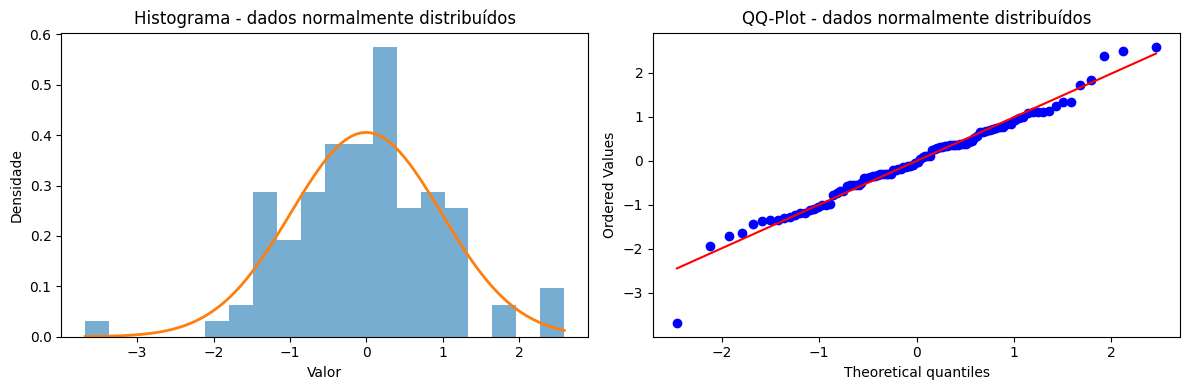


Resultados para dados NÃO normalmente distribuídos
                Teste  Estatística       p-valor  Normal  Alfa  \
0        Shapiro-Wilk     0.807191  4.141911e-10   False  0.05   
1    Anderson-Darling     5.768705           NaN   False  0.05   
2  D'Agostino-Pearson    45.535125  1.294712e-10   False  0.05   
3  Kolmogorov-Smirnov     0.505793  3.200339e-24   False  0.05   

   Valor crítico (5%)  
0                 NaN  
1               0.759  
2                 NaN  
3                 NaN  


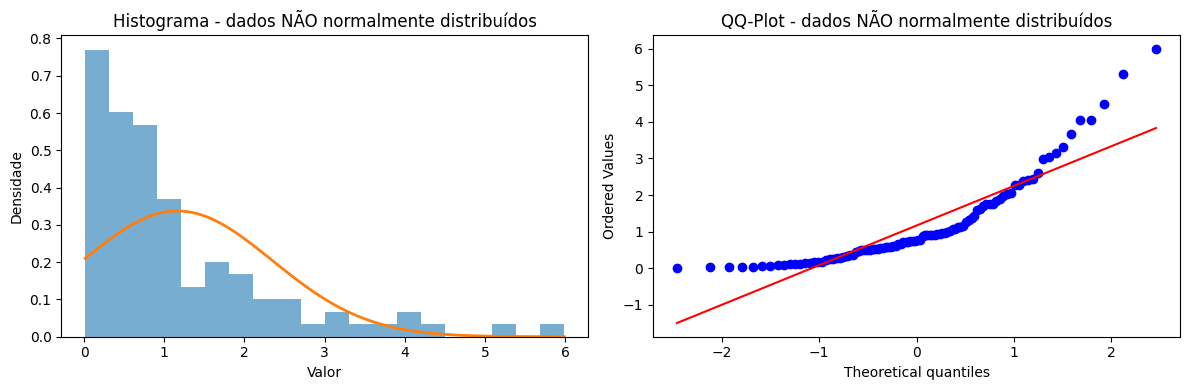

In [ ]:
# Exemplo de uso
np.random.seed(51)
amostra_normal = np.random.normal(loc=0, scale=1, size=100)
amostra_nao_normal = np.random.exponential(scale=1, size=100)

exibir_resultados(amostra_normal, "Resultados para dados normalmente distribuídos")
plot_histogram_qq(amostra_normal, "dados normalmente distribuídos")

exibir_resultados(amostra_nao_normal, "Resultados para dados NÃO normalmente distribuídos")
plot_histogram_qq(amostra_nao_normal, "dados NÃO normalmente distribuídos")


1. Dados Normais
Amostra: [-2.2 -2.  -1.9 -1.8 -1.7] ...


,Teste,Estatística,p-valor,Normal,Alfa,Valor crítico (5%)
0,Shapiro-Wilk,0.973551,0.320831,True,0.050000,nan
1,Anderson-Darling,0.286691,nan,True,0.050000,0.736000
2,D'Agostino-Pearson,5.337461,0.069340,True,0.050000,nan
3,Kolmogorov-Smirnov,0.101345,0.646209,True,0.050000,nan


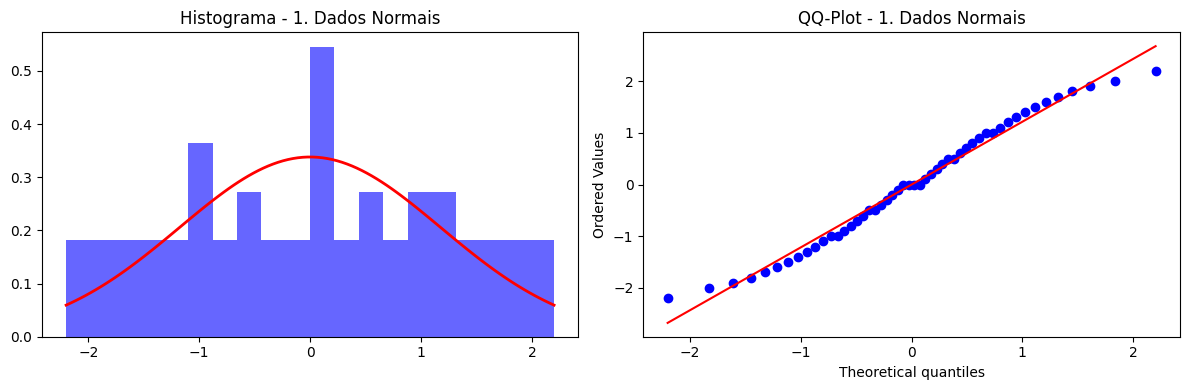


2. Dados Assimétricos
Amostra: [1 1 1 2 2] ...


,Teste,Estatística,p-valor,Normal,Alfa,Valor crítico (5%)
0,Shapiro-Wilk,0.777890,0.000027,False,0.050000,nan
1,Anderson-Darling,2.407647,nan,False,0.050000,0.712000
2,D'Agostino-Pearson,17.184179,0.000186,False,0.050000,nan
3,Kolmogorov-Smirnov,0.877250,0.000000,False,0.050000,nan


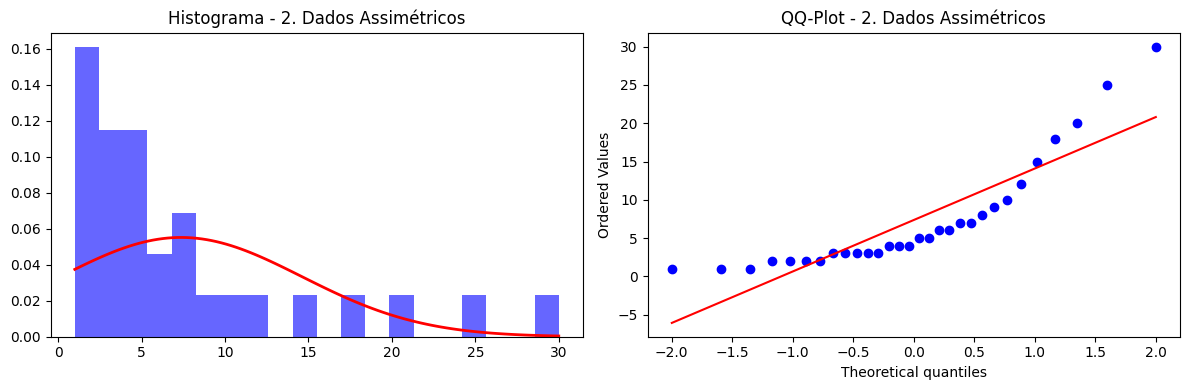


3. Dados Bimodais
Amostra: [10 10 10 11 11] ...


,Teste,Estatística,p-valor,Normal,Alfa,Valor crítico (5%)
0,Shapiro-Wilk,0.806756,0.000009,False,0.050000,nan
1,Anderson-Darling,3.333533,nan,False,0.050000,0.726000
2,D'Agostino-Pearson,204.647353,0.000000,False,0.050000,nan
3,Kolmogorov-Smirnov,1.000000,0.000000,False,0.050000,nan


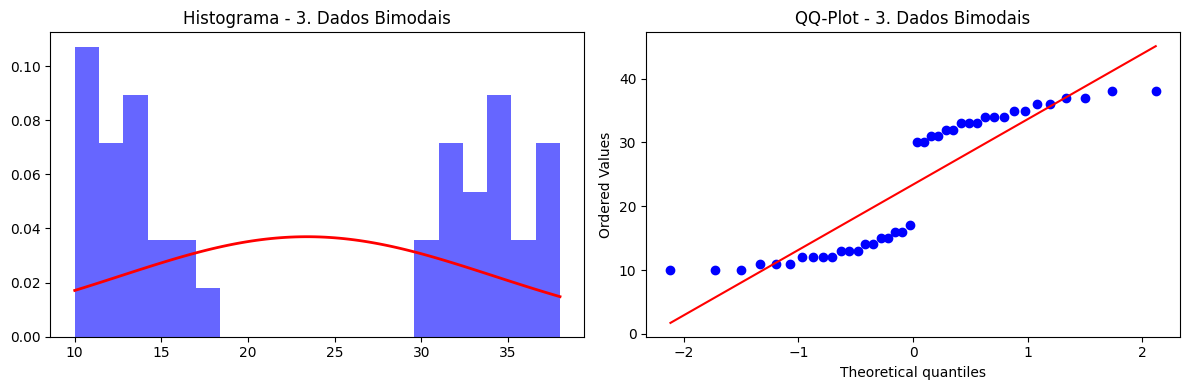


4. Dados Uniformes
Amostra: [1 2 3 4 5] ...


,Teste,Estatística,p-valor,Normal,Alfa,Valor crítico (5%)
0,Shapiro-Wilk,0.939563,0.088526,True,0.050000,nan
1,Anderson-Darling,0.480623,nan,True,0.050000,0.712000
2,D'Agostino-Pearson,6.950310,0.030957,False,0.050000,nan
3,Kolmogorov-Smirnov,0.877250,0.000000,False,0.050000,nan


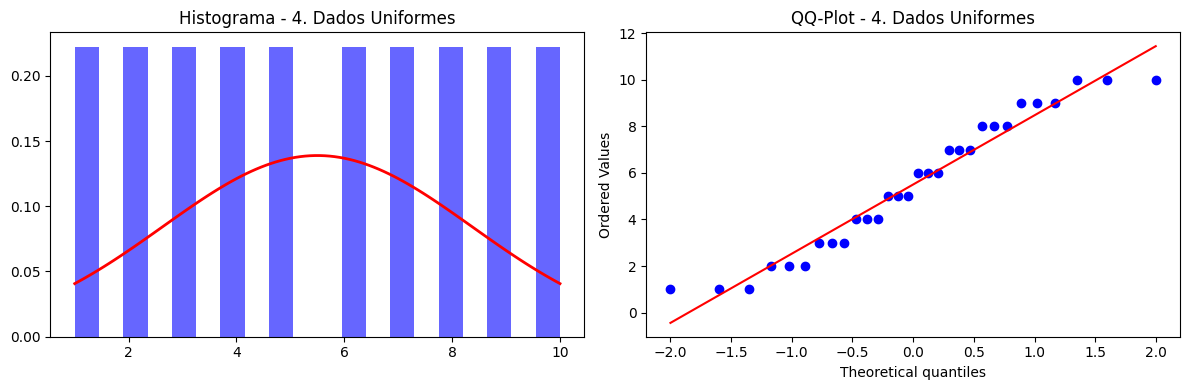


5. Dados com Outliers
Amostra: [-1.  -0.8 -0.6 -0.4 -0.2] ...


,Teste,Estatística,p-valor,Normal,Alfa,Valor crítico (5%)
0,Shapiro-Wilk,0.512428,0.000000,False,0.050000,nan
1,Anderson-Darling,4.973646,nan,False,0.050000,0.699000
2,D'Agostino-Pearson,23.282855,0.000009,False,0.050000,nan
3,Kolmogorov-Smirnov,0.115177,0.886483,True,0.050000,nan


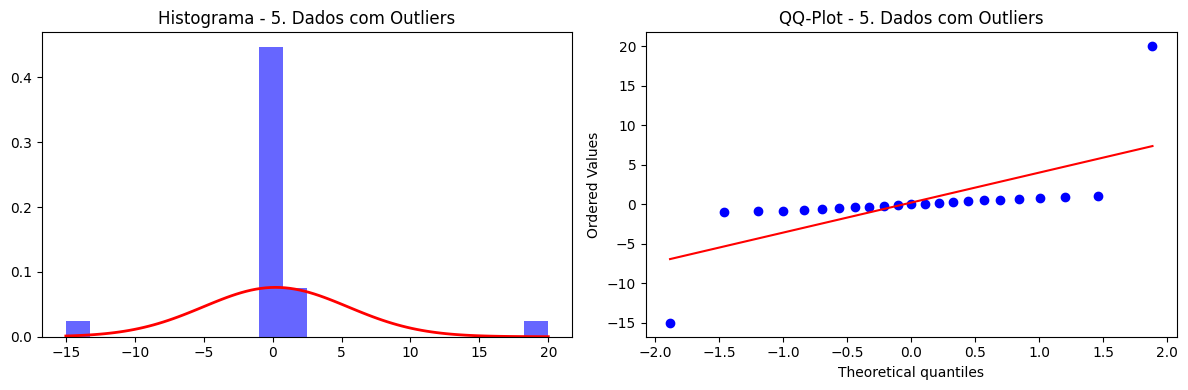

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# --- Versão robusta de todos os testes ---
def teste_shapiro(dados, alpha=0.05):
    try:
        estatistica, p_valor = stats.shapiro(dados)
        return {
            'Teste': 'Shapiro-Wilk',
            'Estatística': estatistica,
            'p-valor': p_valor if not np.isnan(p_valor) else 0.0,  # Evita NaN
            'Normal': p_valor > alpha if not np.isnan(p_valor) else False,
            'Alfa': alpha
        }
    except:
        return {
            'Teste': 'Shapiro-Wilk',
            'Estatística': np.nan,
            'p-valor': 0.0,
            'Normal': False,
            'Alfa': alpha
        }

def teste_anderson(dados, dist='norm'):
    try:
        resultado = stats.anderson(dados, dist=dist)
        # Níveis padrão do teste: [15, 10, 5, 2.5, 1] (sempre pega o 5%)
        valor_critico = resultado.critical_values[2]  # Índice 2 = 5%
        return {
            'Teste': 'Anderson-Darling',
            'Estatística': resultado.statistic,
            'Valor crítico (5%)': valor_critico,
            'Normal': resultado.statistic < valor_critico,
            'Alfa': 0.05
        }
    except:
        return {
            'Teste': 'Anderson-Darling',
            'Estatística': np.nan,
            'Valor crítico (5%)': np.nan,
            'Normal': False,
            'Alfa': 0.05
        }

def teste_dagostino(dados, alpha=0.05):
    try:
        estatistica, p_valor = stats.normaltest(dados)
        return {
            'Teste': "D'Agostino-Pearson",
            'Estatística': estatistica,
            'p-valor': p_valor if not np.isnan(p_valor) else 0.0,
            'Normal': p_valor > alpha if not np.isnan(p_valor) else False,
            'Alfa': alpha
        }
    except:
        return {
            'Teste': "D'Agostino-Pearson",
            'Estatística': np.nan,
            'p-valor': 0.0,
            'Normal': False,
            'Alfa': alpha
        }

def teste_ks(dados, cdf='norm', args=()):
    try:
        estatistica, p_valor = stats.kstest(dados, cdf, args)
        return {
            'Teste': 'Kolmogorov-Smirnov',
            'Estatística': estatistica,
            'p-valor': p_valor if not np.isnan(p_valor) else 0.0,
            'Normal': p_valor > 0.05 if not np.isnan(p_valor) else False,
            'Alfa': 0.05
        }
    except:
        return {
            'Teste': 'Kolmogorov-Smirnov',
            'Estatística': np.nan,
            'p-valor': 0.0,
            'Normal': False,
            'Alfa': 0.05
        }

# --- Funções de visualização ---
def plot_histogram_qq(amostra, descricao):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].hist(amostra, bins=20, density=True, alpha=0.6, color='blue')
    mu, sigma = np.mean(amostra), np.std(amostra)
    x = np.linspace(min(amostra), max(amostra), 100)
    axs[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2)
    axs[0].set_title(f'Histograma - {descricao}')

    stats.probplot(amostra, dist="norm", plot=axs[1])
    axs[1].set_title(f'QQ-Plot - {descricao}')
    plt.tight_layout()
    plt.show()

# --- Conjuntos de dados ---
dados_normais = np.array([
    -2.2, -2.0, -1.9, -1.8, -1.7, -1.6, -1.5, -1.4, -1.3, -1.2,
    -1.1, -1.0, -0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2,
    -0.1,  0.0,  0.0,  0.0,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,
     0.7,  0.8,  0.9,  1.0,  1.1,  1.2,  1.3,  1.4,  1.5,  1.6,
     1.7,  1.8,  1.9,  2.0,  2.2, -1.0, -0.5, 0.0, 0.5, 1.0
])

dados_assimetricos = np.array([1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 5, 5, 6, 6, 7,
                               7, 8, 9, 10, 12, 15, 18, 20, 25, 30])

dados_bimodais = np.array([10, 10, 10, 11, 11, 11, 12, 12, 12, 13,
                           30, 30, 31, 31, 32, 32, 33, 33, 34, 34,
                           12, 13, 13, 14, 14, 15, 15, 16, 16, 17,
                           33, 34, 35, 35, 36, 36, 37, 37, 38, 38])

dados_uniformes = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                            1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                            1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

dados_outliers = np.array([-1.0, -0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8,
                           1.0, -0.9, -0.7, -0.5, -0.3, -0.1, 0.1, 0.3, 0.5, 0.7,
                           0.9, -15.0, 20.0])

# Lista de conjuntos para testar
conjuntos = [
    {'nome': '1. Dados Normais', 'dados': dados_normais},
    {'nome': '2. Dados Assimétricos', 'dados': dados_assimetricos},
    {'nome': '3. Dados Bimodais', 'dados': dados_bimodais},
    {'nome': '4. Dados Uniformes', 'dados': dados_uniformes},
    {'nome': '5. Dados com Outliers', 'dados': dados_outliers}
]

# --- Função de execução ---
def executar_testes(conjunto):
    print(f"\n\033[1m{conjunto['nome']}\033[0m")
    print("Amostra:", conjunto['dados'][:5], "...")  # Mostra apenas os 5 primeiros valores

    resultados = [
        teste_shapiro(conjunto['dados']),
        teste_anderson(conjunto['dados']),
        teste_dagostino(conjunto['dados']),
        teste_ks(conjunto['dados'])
    ]
    display(pd.DataFrame(resultados).style.set_caption(f"Resultados para {conjunto['nome']}"))

    plot_histogram_qq(conjunto['dados'], conjunto['nome'])

# Executar testes para todos os conjuntos
for conjunto in conjuntos:
    executar_testes(conjunto)

<br>
<br>

---
# 2. Teste de Homogeneidade de Variâncias (Homocedasticidade)

<br>
Serve para verificar se diferentes grupos de dados possuem variâncias estatisticamente equivalentes. Esta verificação é fundamental como pressuposto para muitos testes paramétricos, como a ANOVA e o teste t para amostras independentes.
<br><br>
Hipóteses do teste:

H₀ (hipótese nula): As variâncias dos grupos são iguais (homogêneas)

σ₁² = σ₂² = ... = σₖ²

H₁ (hipótese alternativa): Pelo menos um grupo tem variância diferente dos demais
<br><br>
Interpretação dos resultados:

Se p-valor ≥ α (nível de significância, tipicamente 0,05):
Não rejeitamos H₀ → As variâncias podem ser consideradas homogêneas

Se p-valor < α:
Rejeitamos H₀ → Há evidências de heterogeneidade de variâncias

##Exemplo prático no código:
<br>
No nosso exemplo, implementamos três testes principais:

1. Teste de Levene (robusto para distribuições não-normais)

2. Teste de Bartlett (mais preciso para distribuições normais)

3. Teste de Fligner-Killeen (robusto e não paramétrico)
<br>

##Quando usar cada teste?
<br>
Bartlett: Quando os dados são normais e sensível a não-normalidade<br>
Levene:	Para dados normais ou levemente não-normais, e robusto a outliers<br>
Fligner-Killeen: Quando os dados são claramente não-normais, e pouco sensível à distribuição

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.formula.api import ols

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
np.random.seed(42)

#Teste de Levene para homogeneidade de variâncias
def teste_levene(*amostras, center='median'):
    # amostras: arrays de dados (pode ser 2 ou mais grupos)
    # center: 'median' (padrão), 'mean' ou 'trimmed'
    stat, p_valor = stats.levene(*amostras, center=center)
    return {
        'Teste': 'Levene (mediana)' if center == 'median' else f'Levene ({center})',
        'Estatística': stat,
        'p-valor': p_valor,
        'Homocedástico': p_valor > 0.05,
        'Alfa': 0.05
    }

#Teste de Bartlett (mais sensível a não-normalidade)
def teste_bartlett(*amostras):
    stat, p_valor = stats.bartlett(*amostras)
    return {
        'Teste': 'Bartlett',
        'Estatística': stat,
        'p-valor': p_valor,
        'Homocedástico': p_valor > 0.05,
        'Alfa': 0.05
    }

#Teste de Fligner-Killeen (robusto a não-normalidade)
def teste_fligner(*amostras):
    stat, p_valor = stats.fligner(*amostras)
    return {
        'Teste': 'Fligner-Killeen',
        'Estatística': stat,
        'p-valor': p_valor,
        'Homocedástico': p_valor > 0.05,
        'Alfa': 0.05
    }

#Teste de Breusch-Pagan (para modelos de regressão)
def teste_breusch_pagan(residuos, exog):
    lm, lm_p_valor, fstat, fstat_p_valor = het_breuschpagan(residuos, exog)
    return {
        'Teste': 'Breusch-Pagan',
        'Estatística LM': lm,
        'p-valor LM': lm_p_valor,
        'Estatística F': fstat,
        'p-valor F': fstat_p_valor,
        'Homocedástico': lm_p_valor > 0.05,
        'Alfa': 0.05
    }

#Teste de White (para modelos de regressão)
def teste_white(residuos, exog):
    lm, lm_p_valor, fstat, fstat_p_valor = het_white(residuos, exog)
    return {
        'Teste': 'White',
        'Estatística LM': lm,
        'p-valor LM': lm_p_valor,
        'Estatística F': fstat,
        'p-valor F': fstat_p_valor,
        'Homocedástico': lm_p_valor > 0.05,
        'Alfa': 0.05
    }

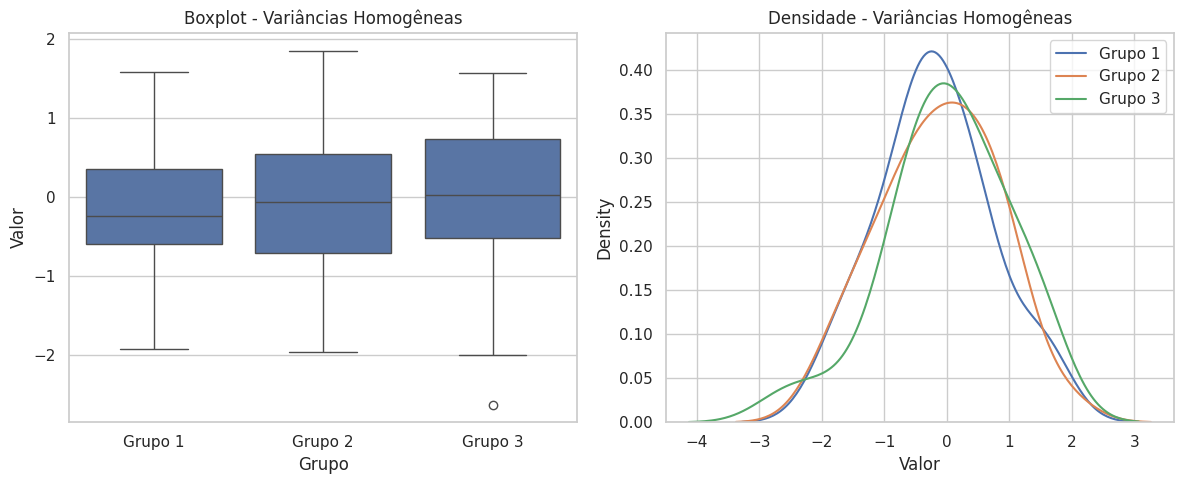

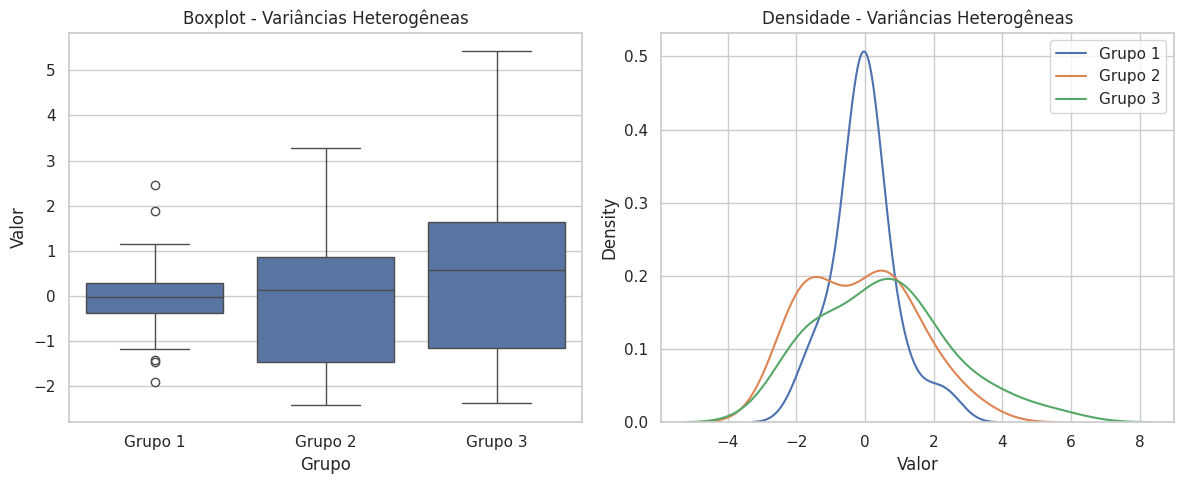

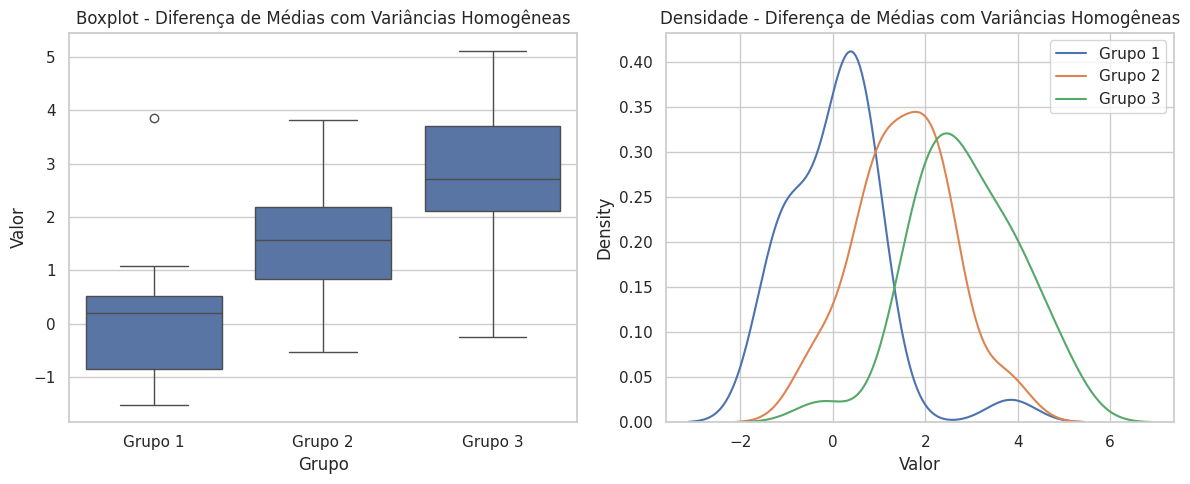

In [ ]:
def gerar_amostras(n=30, num_grupos=3, heterocedasticidade=False, diferenca_media=0):
    """
    Gera amostras com variâncias homogêneas ou heterogêneas
    """
    amostras = []
    grupos = []

    for i in range(num_grupos):
        if heterocedasticidade:
            # Variância aumenta com o número do grupo
            scale = 1 + i*0.5
        else:
            scale = 1

        grupo = stats.norm.rvs(loc=diferenca_media*i, scale=scale, size=n)
        amostras.append(grupo)
        grupos.extend([f'Grupo {i+1}'] * n)

    dados = pd.DataFrame({
        'Valor': np.concatenate(amostras),
        'Grupo': grupos
    })

    return amostras, dados

# Gerar diferentes cenários
amostras_homo, dados_homo = gerar_amostras(heterocedasticidade=False)
amostras_hetero, dados_hetero = gerar_amostras(heterocedasticidade=True)
amostras_media_diff, dados_media_diff = gerar_amostras(diferenca_media=1.5)


def plotar_amostras(dados, titulo):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.boxplot(x='Grupo', y='Valor', data=dados)
    plt.title(f'Boxplot - {titulo}')

    plt.subplot(1, 2, 2)
    for grupo in dados['Grupo'].unique():
        sns.kdeplot(dados[dados['Grupo'] == grupo]['Valor'], label=grupo)
    plt.title(f'Densidade - {titulo}')
    plt.legend()

    plt.tight_layout()
    plt.show()

plotar_amostras(dados_homo, "Variâncias Homogêneas")
plotar_amostras(dados_hetero, "Variâncias Heterogêneas")
plotar_amostras(dados_media_diff, "Diferença de Médias com Variâncias Homogêneas")

def executar_testes_homogeneidade(amostras, dados):
    print("\n" + "="*60)
    print(f"Análise de Homogeneidade de Variâncias")
    print("="*60)

    # Testes para grupos independentes
    resultados = [
        teste_levene(*amostras),
        teste_levene(*amostras, center='mean'),
        teste_bartlett(*amostras),
        teste_fligner(*amostras)
    ]

    # Preparar dados para testes de regressão
    modelo = ols('Valor ~ Grupo', data=dados).fit()
    residuos = modelo.resid
    exog = modelo.model.exog

    # Testes para modelos de regressão
    resultados.append(teste_breusch_pagan(residuos, exog))
    resultados.append(teste_white(residuos, exog))

    # Exibir resultados
    display(pd.DataFrame(resultados))

    # Plotar resíduos vs valores ajustados para regressão
    plt.figure(figsize=(10, 5))
    plt.scatter(modelo.fittedvalues, residuos)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Valores Ajustados')
    plt.ylabel('Resíduos')
    plt.title('Resíduos vs Valores Ajustados')
    plt.show()

    return resultados


CASO 1: VARIÂNCIAS HOMOGÊNEAS

Análise de Homogeneidade de Variâncias


,Teste,Estatística,p-valor,Homocedástico,Alfa,Estatística LM,p-valor LM,Estatística F,p-valor F
0,Levene (mediana),0.147981,0.862664,True,0.05,NaN,NaN,NaN,NaN
1,Levene (mean),0.127774,0.880217,True,0.05,NaN,NaN,NaN,NaN
2,Bartlett,0.281031,0.868910,True,0.05,NaN,NaN,NaN,NaN
3,Fligner-Killeen,0.399925,0.818762,True,0.05,NaN,NaN,NaN,NaN
4,Breusch-Pagan,NaN,NaN,True,0.05,0.322804,0.85095,0.156584,0.8553
5,White,NaN,NaN,True,0.05,0.322804,0.85095,0.156584,0.8553


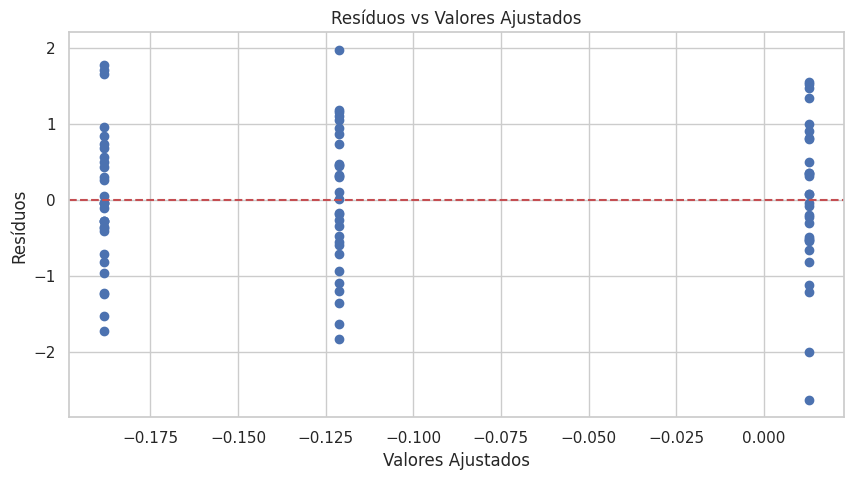


CASO 2: VARIÂNCIAS HETEROGÊNEAS

Análise de Homogeneidade de Variâncias


,Teste,Estatística,p-valor,Homocedástico,Alfa,Estatística LM,p-valor LM,Estatística F,p-valor F
0,Levene (mediana),6.697171,0.001971,False,0.05,NaN,NaN,NaN,NaN
1,Levene (mean),7.122914,0.001365,False,0.05,NaN,NaN,NaN,NaN
2,Bartlett,14.244162,0.000807,False,0.05,NaN,NaN,NaN,NaN
3,Fligner-Killeen,11.252375,0.003602,False,0.05,NaN,NaN,NaN,NaN
4,Breusch-Pagan,NaN,NaN,False,0.05,9.167032,0.010219,4.933208,0.009344
5,White,NaN,NaN,False,0.05,9.167032,0.010219,4.933208,0.009344


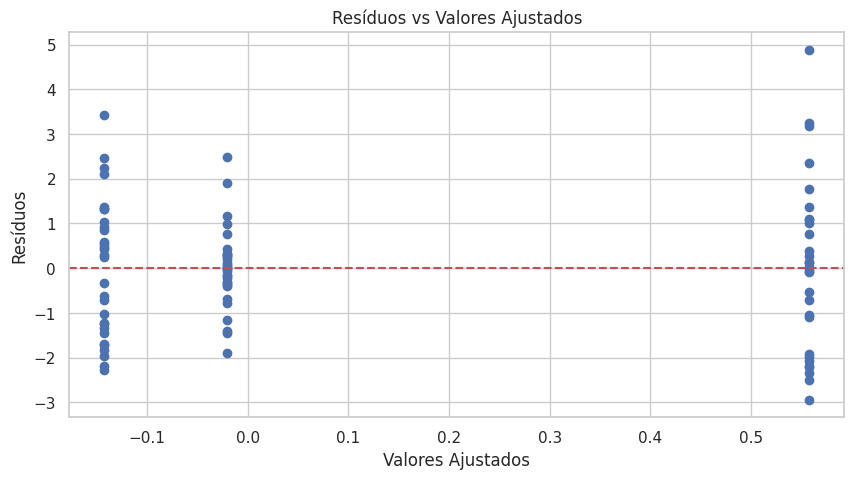


CASO 3: DIFERENÇA DE MÉDIAS COM VARIÂNCIAS HOMOGÊNEAS

Análise de Homogeneidade de Variâncias


,Teste,Estatística,p-valor,Homocedástico,Alfa,Estatística LM,p-valor LM,Estatística F,p-valor F
0,Levene (mediana),0.388541,0.679216,True,0.05,NaN,NaN,NaN,NaN
1,Levene (mean),0.387215,0.680109,True,0.05,NaN,NaN,NaN,NaN
2,Bartlett,0.417998,0.811396,True,0.05,NaN,NaN,NaN,NaN
3,Fligner-Killeen,1.042309,0.593835,True,0.05,NaN,NaN,NaN,NaN
4,Breusch-Pagan,NaN,NaN,True,0.05,0.287354,0.866167,0.139333,0.870132
5,White,NaN,NaN,True,0.05,0.287354,0.866167,0.139333,0.870132


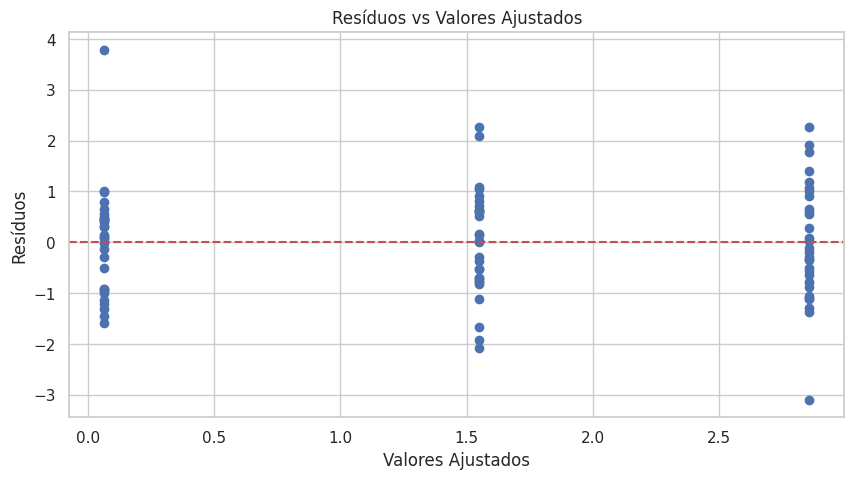

In [ ]:
print("\nCASO 1: VARIÂNCIAS HOMOGÊNEAS")
resultados_homo = executar_testes_homogeneidade(amostras_homo, dados_homo)

print("\nCASO 2: VARIÂNCIAS HETEROGÊNEAS")
resultados_hetero = executar_testes_homogeneidade(amostras_hetero, dados_hetero)

print("\nCASO 3: DIFERENÇA DE MÉDIAS COM VARIÂNCIAS HOMOGÊNEAS")
resultados_media_diff = executar_testes_homogeneidade(amostras_media_diff, dados_media_diff)

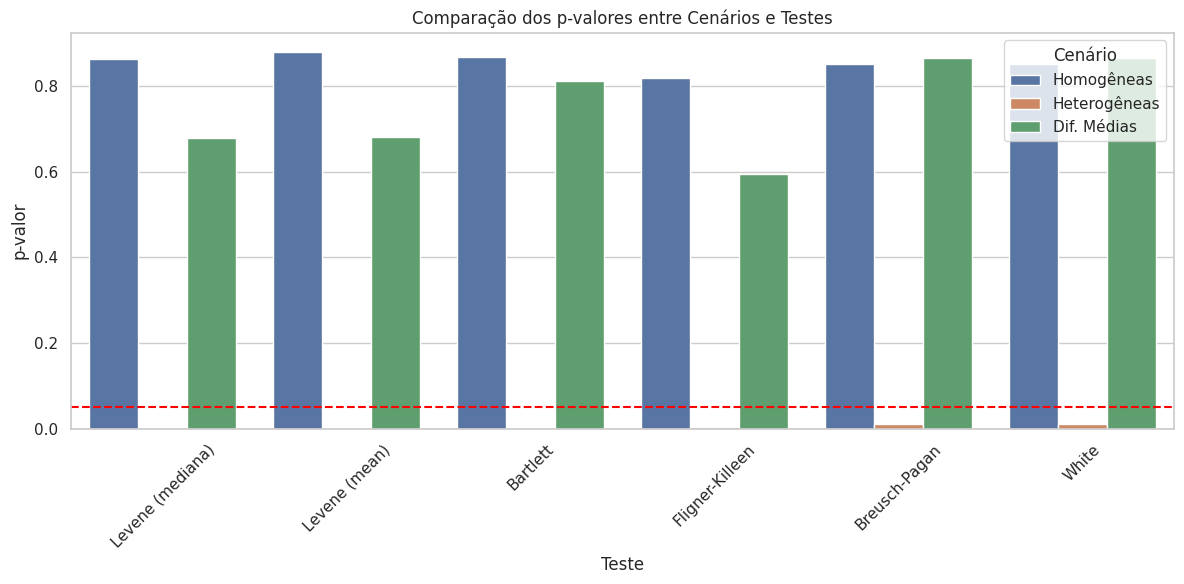

Conclusão                                     p-valor  \
Cenário             Dif. Médias     Heterogêneas     Homogêneas Dif. Médias   
Teste                                                                         
Bartlett          Homocedástico  Heterocedástico  Homocedástico    0.811396   
Breusch-Pagan     Homocedástico  Heterocedástico  Homocedástico    0.866167   
Fligner-Killeen   Homocedástico  Heterocedástico  Homocedástico    0.593835   
Levene (mean)     Homocedástico  Heterocedástico  Homocedástico    0.680109   
Levene (mediana)  Homocedástico  Heterocedástico  Homocedástico    0.679216   
White             Homocedástico  Heterocedástico  Homocedástico    0.866167   

                                          
Cenário          Heterogêneas Homogêneas  
Teste                                     
Bartlett             0.000807   0.868910  
Breusch-Pagan        0.010219   0.850950  
Fligner-Killeen      0.003602   0.818762  
Levene (mean)        0.001365   0.880217  
Levene (mediana)     0.001971   0.862664  
White                0.010219   0.850950

In [ ]:
def comparar_resultados(resultados_lista, cenarios):
    comparacao = []

    for i, resultados in enumerate(resultados_lista):
        for teste in resultados:
            comparacao.append({
                'Cenário': cenarios[i],
                'Teste': teste['Teste'],
                'p-valor': teste.get('p-valor', teste.get('p-valor LM', np.nan)),
                'Conclusão': 'Homocedástico' if teste['Homocedástico'] else 'Heterocedástico'
            })

    df_comparacao = pd.DataFrame(comparacao)

    plt.figure(figsize=(12, 6))
    sns.barplot(x='Teste', y='p-valor', hue='Cenário', data=df_comparacao)
    plt.axhline(y=0.05, color='red', linestyle='--')
    plt.title('Comparação dos p-valores entre Cenários e Testes')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return df_comparacao.pivot_table(index='Teste', columns='Cenário',
                                   values=['p-valor', 'Conclusão'],
                                   aggfunc='first')

# Executar comparação
cenarios = ['Homogêneas', 'Heterogêneas', 'Dif. Médias']
resultados_todos = [resultados_homo, resultados_hetero, resultados_media_diff]
tabela_comparativa = comparar_resultados(resultados_todos, cenarios)
display(tabela_comparativa)

In [ ]:
def recomendar_testes(dados):
    """
    Função para recomendar testes de homogeneidade de variâncias
    com base na normalidade dos dados de cada grupo
    """
    # Primeiro verificar normalidade em cada grupo
    grupos = dados['Grupo'].unique()
    normalidade = True

    for grupo in grupos:
        # Extrair apenas os valores numéricos do grupo
        valores = dados[dados['Grupo'] == grupo]['Valor'].values
        # Aplicar teste de Shapiro-Wilk
        stat, p_valor = stats.shapiro(valores)
        if p_valor <= 0.05:
            normalidade = False
            print(f"{grupo} não é normal (p-valor={p_valor:.4f})")
        else:
            print(f"{grupo} é normal (p-valor={p_valor:.4f})")

    # Separar os dados por grupo para os testes de homogeneidade
    amostras = [dados[dados['Grupo'] == grupo]['Valor'].values for grupo in grupos]

    if normalidade:
        print("\nDados normais - Use Bartlett ou Levene")
        resultado = teste_bartlett(*amostras)
    else:
        print("\nDados não-normais - Use Fligner-Killeen ou Levene com mediana")
        resultado = teste_fligner(*amostras)

    # Exibir resultado do teste recomendado
    print("\nResultado do teste recomendado:")
    display(pd.DataFrame([resultado]))

    return resultado

print("\nRecomendação para dados homogêneos:")
result_homo = recomendar_testes(dados_homo)

print("\nRecomendação para dados heterogêneos:")
result_hetero = recomendar_testes(dados_hetero)

print("\nRecomendação para dados com diferença de médias:")
result_media_diff = recomendar_testes(dados_media_diff)


Recomendação para dados homogêneos:
Grupo 1 é normal (p-valor=0.6868)
Grupo 2 é normal (p-valor=0.9130)
Grupo 3 é normal (p-valor=0.3654)

Dados normais - Use Bartlett ou Levene

Resultado do teste recomendado:


,Teste,Estatística,p-valor,Homocedástico,Alfa
0,Bartlett,0.281031,0.86891,True,0.05



Recomendação para dados heterogêneos:
Grupo 1 é normal (p-valor=0.1565)
Grupo 2 é normal (p-valor=0.2481)
Grupo 3 é normal (p-valor=0.2529)

Dados normais - Use Bartlett ou Levene

Resultado do teste recomendado:


,Teste,Estatística,p-valor,Homocedástico,Alfa
0,Bartlett,14.244162,0.000807,False,0.05



Recomendação para dados com diferença de médias:
Grupo 1 não é normal (p-valor=0.0014)
Grupo 2 é normal (p-valor=0.6831)
Grupo 3 é normal (p-valor=0.6891)

Dados não-normais - Use Fligner-Killeen ou Levene com mediana

Resultado do teste recomendado:


,Teste,Estatística,p-valor,Homocedástico,Alfa
0,Fligner-Killeen,1.042309,0.593835,True,0.05


<br>
<br>

---
#3. Testes para Média Populacional
<br>

Testes para média populacional são procedimentos estatísticos que nos permitem avaliar hipóteses sobre o valor médio de uma característica em uma população, com base em dados amostrais. Esses testes comparam a média observada na amostra com um valor de referência (no caso de uma amostra) ou comparam médias entre grupos (no caso de duas ou mais amostras).



##Principais tipos de testes:
<br>

Teste t para uma amostra:
- O que testa: Se a média da população difere de um valor específico

- Fórmula: t = (x̄ - μ₀) / (s/√n)

- Exemplo: Testar se a altura média dos alunos de uma escola difere da média nacional
<br>

Teste t para duas amostras independentes:

- O que testa: Se duas populações têm médias diferentes

- Fórmula: t = (x̄₁ - x̄₂) / √(s₁²/n₁ + s₂²/n₂)

- Exemplo: Comparar o rendimento médio de duas culturas diferentes
<br>

Teste t pareado:

- O que testa: Se há diferença entre médias de medidas repetidas

- Fórmula: t = d̄ / (s_d/√n)

- Exemplo: Comparar o desempenho de pacientes antes e depois de um tratamento
<br>

ANOVA (para três ou mais médias):

- O que testa: Se pelo menos uma média difere entre múltiplos grupos

- Exemplo: Comparar a eficácia de três medicamentos diferentes

##Quando usar cada teste?
<br>

Teste t para uma amostra:<br>
- Situação: Comparar uma média com valor teórico
- Teste Não-Paramétrico Alternativo: Teste do sinal / Wilcoxon
<br>

Teste t independente:<br>
- Situação: Comparar duas médias independentes
- Teste Não-Paramétrico Alternativo: Mann-Whitney U
<br>

Teste t pareado:<br>
- Situação: Comparar duas médias pareadas
- Teste Não-Paramétrico Alternativo: Wilcoxon pareado

ANOVA:<br>
- Situação: Comparar três ou mais médias
- Teste Não-Paramétrico Alternativo: Kruskal-Wallis

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_palette("husl")
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)

#Teste t para média de uma amostra
def teste_t_uma_amostra(amostra, mu0, alpha=0.05, alternativa='two-sided'):
    """
        amostra: array com os dados
        mu0: valor da média populacional sob H0
        alpha: nível de significância
        alternativa: 'two-sided', 'less' ou 'greater'
    """
    resultado = stats.ttest_1samp(amostra, popmean=mu0, alternative=alternativa)

    decisao = "Rejeitar H0" if resultado.pvalue < alpha else "Não rejeitar H0"

    return {
        'Teste': 'Teste t (uma amostra)',
        'H0': f'μ = {mu0}',
        'H1': f'μ ≠ {mu0}' if alternativa == 'two-sided' else f'μ {">" if alternativa == "greater" else "<"} {mu0}',
        'Média amostral': np.mean(amostra),
        'Estatística t': resultado.statistic,
        'Graus de liberdade': len(amostra) - 1,
        'p-valor': resultado.pvalue,
        'Alpha': alpha,
        'Decisão': decisao,
        'IC 95%': stats.t.interval(0.95, df=len(amostra)-1,
                              loc=np.mean(amostra),
                              scale=stats.sem(amostra))
    }

#Teste t para médias de duas amostras independentes
def teste_t_independentes(amostra1, amostra2, alpha=0.05, var_iguais=False, alternativa='two-sided'):
    """
        var_iguais: se True, usa teste t padrão com variâncias iguais
                   se False, usa teste t de Welch (variâncias diferentes)
    """
    if var_iguais:
        resultado = stats.ttest_ind(amostra1, amostra2,
                                 equal_var=True,
                                 alternative=alternativa)
        tipo = 'Teste t (variâncias iguais)'
    else:
        resultado = stats.ttest_ind(amostra1, amostra2,
                                 equal_var=False,
                                 alternative=alternativa)
        tipo = 'Teste t de Welch (variâncias diferentes)'

    decisao = "Rejeitar H0" if resultado.pvalue < alpha else "Não rejeitar H0"

    return {
        'Teste': tipo,
        'H0': 'μ1 = μ2',
        'H1': 'μ1 ≠ μ2' if alternativa == 'two-sided' else f'μ1 {">" if alternativa == "greater" else "<"} μ2',
        'Média amostra 1': np.mean(amostra1),
        'Média amostra 2': np.mean(amostra2),
        'Estatística t': resultado.statistic,
        'Graus de liberdade': resultado.df,
        'p-valor': resultado.pvalue,
        'Alpha': alpha,
        'Decisão': decisao,
        'IC 95% diferença': stats.t.interval(0.95, df=resultado.df,
                                         loc=np.mean(amostra1)-np.mean(amostra2),
                                         scale=np.sqrt(np.var(amostra1)/len(amostra1) + np.var(amostra2)/len(amostra2)))
    }

#Teste t para amostras pareadas/relacionadas
def teste_t_pareado(antes, depois, alpha=0.05, alternativa='two-sided'):
    resultado = stats.ttest_rel(antes, depois, alternative=alternativa)

    diferencas = np.array(depois) - np.array(antes)
    decisao = "Rejeitar H0" if resultado.pvalue < alpha else "Não rejeitar H0"

    return {
        'Teste': 'Teste t pareado',
        'H0': 'μ_antes = μ_depois',
        'H1': 'μ_antes ≠ μ_depois' if alternativa == 'two-sided' else f'μ_antes {">" if alternativa == "greater" else "<"} μ_depois',
        'Média antes': np.mean(antes),
        'Média depois': np.mean(depois),
        'Média diferenças': np.mean(diferencas),
        'Estatística t': resultado.statistic,
        'Graus de liberdade': len(antes) - 1,
        'p-valor': resultado.pvalue,
        'Alpha': alpha,
        'Decisão': decisao,
        'IC 95% diferenças': stats.t.interval(0.95, df=len(diferencas)-1,
                                          loc=np.mean(diferencas),
                                          scale=stats.sem(diferencas))
    }

#Teste não paramétrico de Wilcoxon para amostras pareadas (alternativa ao t pareado)
def teste_wilcoxon_pareado(antes, depois, alpha=0.05, alternativa='two-sided'):
    resultado = stats.wilcoxon(antes, depois, alternative=alternativa)

    diferencas = np.array(depois) - np.array(antes)
    decisao = "Rejeitar H0" if resultado.pvalue < alpha else "Não rejeitar H0"

    return {
        'Teste': 'Wilcoxon (pareado)',
        'H0': 'Distribuição antes = Distribuição depois',
        'H1': 'Distribuições diferentes' if alternativa == 'two-sided' else f'Distrib. depois {">" if alternativa == "greater" else "<"} distrib. antes',
        'Estatística': resultado.statistic,
        'p-valor': resultado.pvalue,
        'Alpha': alpha,
        'Decisão': decisao
    }

In [ ]:
def gerar_dados_exemplo(n=30, mu1=0, mu2=1, sigma1=1, sigma2=1.5, pareado=False):
    grupo1 = stats.norm.rvs(loc=mu1, scale=sigma1, size=n)

    if pareado:
        # Para dados pareados, criamos diferenças correlacionadas
        diferencas = stats.norm.rvs(loc=mu2-mu1, scale=0.5, size=n)
        grupo2 = grupo1 + diferencas
    else:
        grupo2 = stats.norm.rvs(loc=mu2, scale=sigma2, size=n)

    return grupo1, grupo2

def plotar_comparacao_medias(grupo1, grupo2, titulo, pareado=False):
    fig, axs = plt.subplots(1, 2 if not pareado else 3, figsize=(15, 5))

    # Boxplot
    if not pareado:
        sns.boxplot(data=[grupo1, grupo2], ax=axs[0])
        axs[0].set_xticklabels(['Grupo 1', 'Grupo 2'])
    else:
        diferencas = grupo2 - grupo1
        sns.boxplot(data=[grupo1, grupo2, diferencas], ax=axs[0])
        axs[0].set_xticklabels(['Antes', 'Depois', 'Diferenças'])
    axs[0].set_title('Boxplot')

    # Histograma
    sns.histplot(grupo1, kde=True, color='blue', label='Grupo 1', ax=axs[1])
    sns.histplot(grupo2, kde=True, color='orange', label='Grupo 2', ax=axs[1])
    axs[1].legend()
    axs[1].set_title('Distribuição')

    if pareado:
        # Gráfico de antes-depois para dados pareados
        for i in range(len(grupo1)):
            axs[2].plot([0, 1], [grupo1[i], grupo2[i]], 'k-', alpha=0.3)
        axs[2].plot([0]*len(grupo1), grupo1, 'bo', label='Antes')
        axs[2].plot([1]*len(grupo2), grupo2, 'ro', label='Depois')
        axs[2].set_xticks([0, 1])
        axs[2].set_xticklabels(['Antes', 'Depois'])
        axs[2].set_title('Dados Pareados')
        axs[2].legend()

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

In [ ]:
# Exemplo 1: Teste t para uma amostra
# Gerar dados com média 5 e desvio padrão 2
dados = stats.norm.rvs(loc=5, scale=2, size=100)

# Testar se a média é igual a 4.5
resultado = teste_t_uma_amostra(dados, mu0=4.5)
pd.DataFrame([resultado])

,Teste,H0,H1,Média amostral,Estatística t,Graus de liberdade,p-valor,Alpha,Decisão,IC 95%
0,Teste t (uma amostra),μ = 4.5,μ ≠ 4.5,4.7923,1.6093,99,0.1107,0.0500,Não rejeitar H0,"(4.431906327276198, 5.152707603147426)"


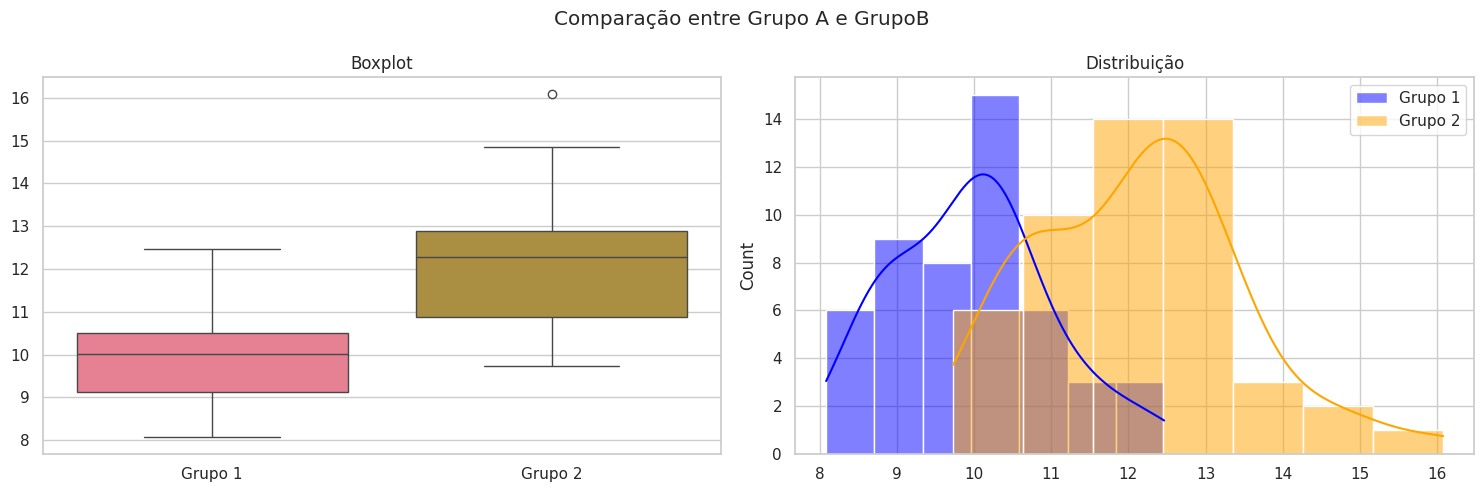

,Teste,H0,H1,Média amostra 1,Média amostra 2,Estatística t,Graus de liberdade,p-valor,Alpha,Decisão,IC 95% diferença
0,Teste t (variâncias iguais),μ1 = μ2,μ1 ≠ μ2,9.9607,12.1258,-9.1036,98.0000,0.0000,0.0500,Rejeitar H0,"(-2.6323580775971456, -1.697907278049514)"
1,Teste t de Welch (variâncias diferentes),μ1 = μ2,μ1 ≠ μ2,9.9607,12.1258,-9.1036,91.3013,0.0000,0.0500,Rejeitar H0,"(-2.632786905062478, -1.6974784505841813)"


In [ ]:
#Exemplo 2: Teste t para amostras independentes
# Gerar dois grupos com médias diferentes
grupoA, grupoB = gerar_dados_exemplo(mu1=10, mu2=12, n=50)

# Visualizar os dados
plotar_comparacao_medias(grupoA, grupoB, "Comparação entre Grupo A e GrupoB")

# Teste com variâncias iguais
resultado_igual = teste_t_independentes(grupoA, grupoB, var_iguais=True)
# Teste com variâncias diferentes (Welch)
resultado_welch = teste_t_independentes(grupoA, grupoB, var_iguais=False)

# Comparar resultados
pd.DataFrame([resultado_igual, resultado_welch])

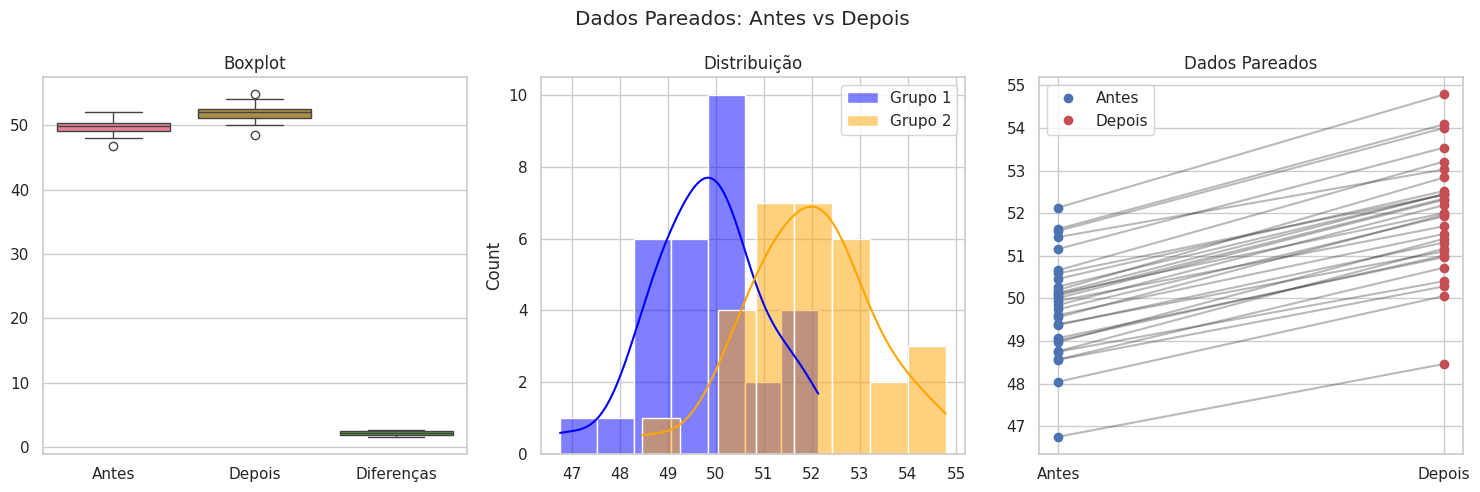

,Teste,H0,H1,Média antes,Média depois,Média diferenças,Estatística t,Graus de liberdade,p-valor,Alpha,Decisão,IC 95% diferenças,Estatística
0,Teste t pareado,μ_antes = μ_depois,μ_antes ≠ μ_depois,49.8161,51.9391,2.1230,-37.1534,29.0000,0.0000,0.0500,Rejeitar H0,"(2.0061440926598983, 2.2398804420956546)",NaN
1,Wilcoxon (pareado),Distribuição antes = Distribuição depois,Distribuições diferentes,NaN,NaN,NaN,NaN,NaN,0.0000,0.0500,Rejeitar H0,NaN,0.0000


In [ ]:
#Exemplo 3: Teste t pareado
# Gerar dados antes-depois com melhoria média de 2 pontos
antes, depois = gerar_dados_exemplo(mu1=50, mu2=52, pareado=True, n=30)

# Visualizar dados
plotar_comparacao_medias(antes, depois, "Dados Pareados: Antes vs Depois", pareado=True)

# Aplicar teste t pareado
resultado_pareado = teste_t_pareado(antes, depois)
# Aplicar Wilcoxon como alternativa não paramétrica
resultado_wilcoxon = teste_wilcoxon_pareado(antes, depois)

# Comparar resultados
pd.DataFrame([resultado_pareado, resultado_wilcoxon])

##Interpretação dos Resultados

Cada teste retorna um dicionário com:

1. Informações sobre as hipóteses (H0 e H1)

2. Estatísticas descritivas (médias amostrais)

3. Estatística do teste (valor t, graus de liberdade)

4. p-valor e decisão ao nível de significância α

5. Intervalo de confiança para a diferença (quando aplicável)

<br>
<br>

---

#4. Testes para Diferença de Médias
<br>

Os testes para diferença de médias são métodos estatísticos que avaliam se as médias de dois ou mais grupos são significativamente diferentes entre si. Eles são amplamente utilizados em pesquisas científicas, experimentos e análises de dados para validar hipóteses comparativas.

São testes que comparam as médias de diferentes amostras para determinar se as diferenças observadas são estatisticamente significativas ou se podem ter ocorrido por acaso.

##Principais tipos de testes:
<br>

1.
- Teste Paramétrico: Teste t para uma amostra
- Tipo de Comparação: Se a média da população difere de um valor específico
- Teste Não-Paramétrico (Alternativa): Teste de Wilcoxon (sinal)
<br>

2.
- Teste Paramétrico: Teste t independente
- Tipo de Comparação: 2 amostras independentes
- Teste Não-Paramétrico (Alternativa): Mann-Whitney U
<br>

3.
- Teste Paramétrico: Teste t pareado
- Tipo de Comparação: 2 amostras relacionadas
- Teste Não-Paramétrico (Alternativa): Wilcoxon pareado
<br>

4.
- Teste Paramétrico: ANOVA
- Tipo de Comparação: 3+ amostras independentes
- Teste Não-Paramétrico (Alternativa): Kruskal-Wallis
<br>

##Quando Usar Cada Teste?
<br>

Teste t para uma amostra:

- O que faz? Compara a média de um grupo com um valor de referência.

- Quando usar? Ex.: "A altura média dos alunos desta escola é igual à média nacional (1,70m)?"

- Pressupostos: Dados contínuos (intervalar ou razão) e distribuição aproximadamente normal (ou amostra grande, n > 30).<br>

Teste t para amostras independentes:

- O que faz? Compara as médias de dois grupos não relacionados.

- Quando usar? Ex.: "O rendimento médio do fertilizante A é diferente do B?"

- Pressupostos: Normalidade (Shapiro-Wilk) e homocedasticidade (variâncias iguais – Levene).<br>

Teste t pareado:

- O que faz? Compara médias do mesmo grupo em dois momentos diferentes.

- Quando usar? Ex.: "O peso médio dos pacientes diminuiu após a dieta?"

- Pressupostos: Diferenças entre pares devem ser normalmente distribuídas.<br>

ANOVA (Análise de Variância):

- O que faz? Compara médias de três ou mais grupos.

- Quando usar? Ex.: "Há diferença no tempo de recuperação entre três tratamentos?"

- Pressupostos: Normalidade, homocedasticidade e independência das observações.

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.weightstats import ttest_ind

sns.set_palette("husl")
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)

#Teste t para amostras independentes (com verificação de homocedasticidade)
def teste_diferenca_medias_independentes(amostra1, amostra2, alpha=0.05, alternativa='two-sided'):
    """
    Testa diferença entre médias de duas amostras independentes com verificação automática
    de homocedasticidade e escolha do teste apropriado.

    Retorna:
    - Resultado do teste de Levene para homogeneidade de variâncias
    - Resultado do teste t apropriado (com variâncias iguais ou diferentes)
    - Tamanho do efeito (Cohen's d)
    """
    # Verificar homogeneidade de variâncias
    levene = stats.levene(amostra1, amostra1)
    var_iguais = levene.pvalue > alpha

    # Executar teste t apropriado
    if var_iguais:
        teste = stats.ttest_ind(amostra1, amostra2, equal_var=True, alternative=alternativa)
        tipo_teste = "Teste t para variâncias iguais"
    else:
        teste = stats.ttest_ind(amostra1, amostra2, equal_var=False, alternative=alternativa)
        tipo_teste = "Teste t de Welch para variâncias diferentes"

    # Calcular tamanho do efeito (Cohen's d)
    n1, n2 = len(amostra1), len(amostra2)
    pooled_std = np.sqrt(((n1-1)*np.var(amostra1, ddof=1) + (n2-1)*np.var(amostra2, ddof=1)) / (n1+n2-2))
    d = (np.mean(amostra1) - np.mean(amostra2)) / pooled_std

    # Resultados
    return {
        'Teste': tipo_teste,
        'H0': 'μ₁ = μ₂',
        'H1': 'μ₁ ≠ μ₂' if alternativa == 'two-sided' else f'μ₁ {">" if alternativa == "greater" else "<"} μ₂',
        'Média amostra 1': np.mean(amostra1),
        'Média amostra 2': np.mean(amostra2),
        'Diferença': np.mean(amostra1) - np.mean(amostra2),
        'Estatística t': teste.statistic,
        'Graus liberdade': teste.df,
        'p-valor': teste.pvalue,
        'Alpha': alpha,
        'Homocedasticidade': var_iguais,
        'p-valor Levene': levene.pvalue,
        'Tamanho efeito (Cohen d)': d,
        'IC 95% diferença': ttest_ind(amostra1, amostra2, alternative=alternativa, usevar='unequal')[1]
    }


#Teste de Mann-Whitney U (não paramétrico para amostras independentes)
def teste_mannwhitneyu(amostra1, amostra2, alpha=0.05, alternativa='two-sided'):
    """
    Teste não paramétrico para diferença entre distribuições de duas amostras independentes.
    """
    teste = stats.mannwhitneyu(amostra1, amostra2, alternative=alternativa)

    # Calcular tamanho do efeito (rank-biserial correlation)
    n1, n2 = len(amostra1), len(amostra2)
    efeito = 1 - (2 * teste.statistic) / (n1 * n2)

    return {
        'Teste': 'Mann-Whitney U',
        'H0': 'Distribuições iguais',
        'H1': 'Distribuições diferentes' if alternativa == 'two-sided' else f'Distribuição 1 {">" if alternativa == "greater" else "<"} Distribuição 2',
        'Mediana amostra 1': np.median(amostra1),
        'Mediana amostra 2': np.median(amostra2),
        'Estatística U': teste.statistic,
        'p-valor': teste.pvalue,
        'Alpha': alpha,
        'Tamanho efeito (r)': efeito
    }

#Teste t pareado para amostras relacionadas
def teste_diferenca_medias_pareadas(antes, depois, alpha=0.05, alternativa='two-sided'):
    """
    Teste t para amostras pareadas/relacionadas com cálculo de tamanho do efeito.
    """
    teste = stats.ttest_rel(antes, depois, alternative=alternativa)
    diferencas = np.array(depois) - np.array(antes)

    # Calcular tamanho do efeito (Cohen's d)
    d = np.mean(diferencas) / np.std(diferencas, ddof=1)

    return {
        'Teste': 'Teste t pareado',
        'H0': 'μ_diferença = 0',
        'H1': 'μ_diferença ≠ 0' if alternativa == 'two-sided' else f'μ_diferença {">" if alternativa == "greater" else "<"} 0',
        'Média antes': np.mean(antes),
        'Média depois': np.mean(depois),
        'Média diferenças': np.mean(diferencas),
        'Estatística t': teste.statistic,
        'Graus liberdade': len(diferencas)-1,
        'p-valor': teste.pvalue,
        'Alpha': alpha,
        'Tamanho efeito (Cohen d)': d,
        'IC 95% diferenças': stats.t.interval(0.95, df=len(diferencas)-1,
                                           loc=np.mean(diferencas),
                                           scale=stats.sem(diferencas))
    }

#Teste de Wilcoxon para amostras pareadas (não paramétrico)
def teste_wilcoxon_pareado(antes, depois, alpha=0.05, alternativa='two-sided'):
    """
    Teste não paramétrico para amostras pareadas.
    """
    teste = stats.wilcoxon(antes, depois, alternative=alternativa)
    diferencas = depois - antes

    # Calcular tamanho do efeito (rank-biserial correlation)
    n = len(diferencas)
    r = teste.statistic / (n * (n + 1) / 2)

    return {
        'Teste': 'Wilcoxon (pareado)',
        'H0': 'Distribuição diferenças é simétrica em torno de zero',
        'H1': 'Distribuição diferenças não é simétrica' if alternativa == 'two-sided' else f'Diferenças tendem a {">" if alternativa == "greater" else "<"} 0',
        'Mediana antes': np.median(antes),
        'Mediana depois': np.median(depois),
        'Mediana diferenças': np.median(diferencas),
        'Estatística': teste.statistic,
        'p-valor': teste.pvalue,
        'Alpha': alpha,
        'Tamanho efeito (r)': r
    }

In [ ]:
def gerar_dados_medias(n=30, mu1=0, mu2=0.5, sigma1=1, sigma2=1, pareado=False, nao_normal=False):
    """
    Gera conjuntos de dados para exemplos de diferença de médias.

    Parâmetros:
    - pareado: se True, gera dados pareados/relacionados
    - nao_normal: se True, gera dados de distribuição não normal
    """
    if nao_normal:
        # Distribuição exponencial (assimétrica)
        grupo1 = stats.expon.rvs(scale=sigma1, size=n) + mu1 - sigma1
        if pareado:
            diferencas = stats.norm.rvs(loc=mu2-mu1, scale=0.5, size=n)
            grupo2 = grupo1 + diferencas
        else:
            grupo2 = stats.expon.rvs(scale=sigma2, size=n) + mu2 - sigma2
    else:
        # Distribuição normal
        grupo1 = stats.norm.rvs(loc=mu1, scale=sigma1, size=n)
        if pareado:
            diferencas = stats.norm.rvs(loc=mu2-mu1, scale=0.5, size=n)
            grupo2 = grupo1 + diferencas
        else:
            grupo2 = stats.norm.rvs(loc=mu2, scale=sigma2, size=n)

    return grupo1, grupo2

def plotar_comparacao_medias(grupo1, grupo2, titulo, pareado=False):
    """
    Cria gráficos comparativos para análise de diferenças entre médias.
    """
    fig, axs = plt.subplots(1, 2 if not pareado else 3, figsize=(15, 5))

    # Boxplot
    if not pareado:
        sns.boxplot(data=[grupo1, grupo2], ax=axs[0])
        axs[0].set_xticklabels(['Grupo 1', 'Grupo 2'])
    else:
        diferencas = grupo2 - grupo1
        sns.boxplot(data=[grupo1, grupo2, diferencas], ax=axs[0])
        axs[0].set_xticklabels(['Antes', 'Depois', 'Diferenças'])
    axs[0].set_title('Boxplot')

    # Histograma
    sns.histplot(grupo1, kde=True, color='blue', label='Grupo 1', ax=axs[1])
    sns.histplot(grupo2, kde=True, color='orange', label='Grupo 2', ax=axs[1])
    axs[1].legend()
    axs[1].set_title('Distribuição')

    if pareado:
        # Gráfico de antes-depois para dados pareados
        for i in range(len(grupo1)):
            axs[2].plot([0, 1], [grupo1[i], grupo2[i]], 'k-', alpha=0.3)
        axs[2].plot([0]*len(grupo1), grupo1, 'bo', label='Antes')
        axs[2].plot([1]*len(grupo2), grupo2, 'ro', label='Depois')
        axs[2].set_xticks([0, 1])
        axs[2].set_xticklabels(['Antes', 'Depois'])
        axs[2].set_title('Dados Pareados')
        axs[2].legend()

    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

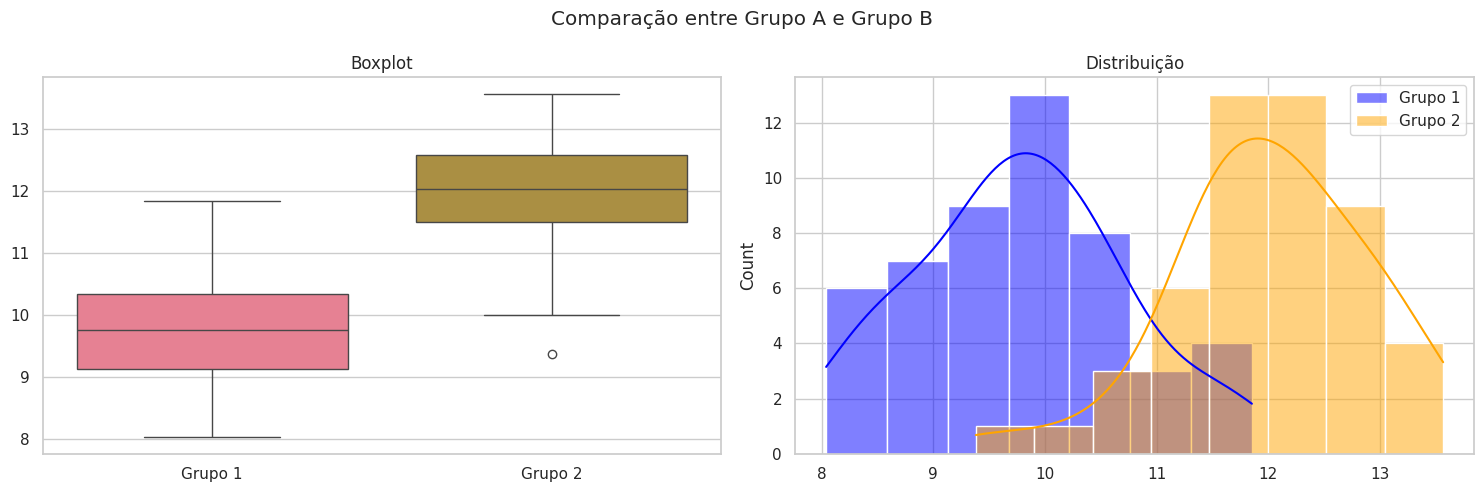

=== Teste Paramétrico ===


,Teste,H0,H1,Média amostra 1,Média amostra 2,Diferença,Estatística t,Graus liberdade,p-valor,Alpha,Homocedasticidade,p-valor Levene,Tamanho efeito (Cohen d),IC 95% diferença
0,Teste t para variâncias iguais,μ₁ = μ₂,μ₁ ≠ μ₂,9.7745,12.0178,-2.2433,-12.4007,98.0000,0.0000,0.0500,True,1.0000,-2.4801,0.0000



=== Teste Não Paramétrico ===


,Teste,H0,H1,Mediana amostra 1,Mediana amostra 2,Estatística U,p-valor,Alpha,Tamanho efeito (r)
0,Mann-Whitney U,Distribuições iguais,Distribuições diferentes,9.7659,12.0461,117.0000,0.0000,0.0500,0.9064


In [ ]:
#Exemplo 1: Amostras independentes (dados normais)
# Gerar dados
grupoA, grupoB = gerar_dados_medias(mu1=10, mu2=12, n=50)

# Visualizar
plotar_comparacao_medias(grupoA, grupoB, "Comparação entre Grupo A e Grupo B")

# Teste paramétrico
resultado_t = teste_diferenca_medias_independentes(grupoA, grupoB)
# Teste não paramétrico
resultado_mw = teste_mannwhitneyu(grupoA, grupoB)

# Resultados
print("=== Teste Paramétrico ===")
display(pd.DataFrame([resultado_t]))
print("\n=== Teste Não Paramétrico ===")
display(pd.DataFrame([resultado_mw]))

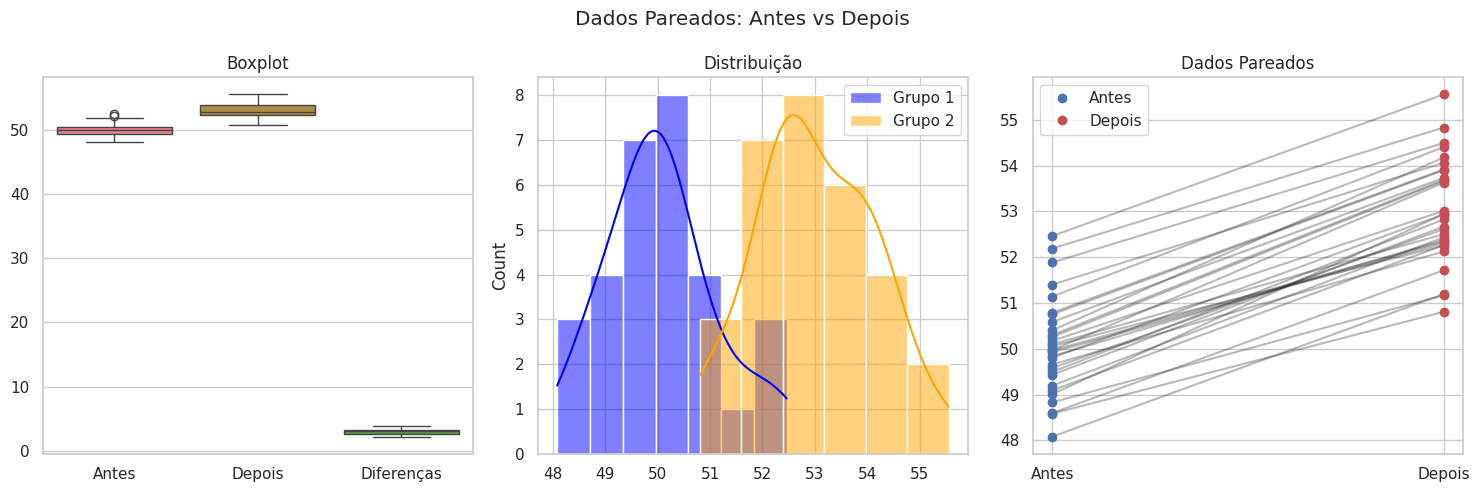

=== Teste Paramétrico ===


,Teste,H0,H1,Média antes,Média depois,Média diferenças,Estatística t,Graus liberdade,p-valor,Alpha,Tamanho efeito (Cohen d),IC 95% diferenças
0,Teste t pareado,μ_diferença = 0,μ_diferença ≠ 0,50.0528,53.0192,2.9664,-34.7829,29,0.0000,0.0500,6.3505,"(2.7919880283528364, 3.140837406706595)"



=== Teste Não Paramétrico ===


,Teste,H0,H1,Mediana antes,Mediana depois,Mediana diferenças,Estatística,p-valor,Alpha,Tamanho efeito (r)
0,Wilcoxon (pareado),Distribuição diferenças é simétrica em torno d...,Distribuição diferenças não é simétrica,49.9694,52.8812,3.1149,0.0000,0.0000,0.0500,0.0000


In [ ]:
#Exemplo 2: Amostras pareadas (dados normais)
# Gerar dados
antes, depois = gerar_dados_medias(mu1=50, mu2=53, pareado=True, n=30)

# Visualizar
plotar_comparacao_medias(antes, depois, "Dados Pareados: Antes vs Depois", pareado=True)

# Teste paramétrico
resultado_t = teste_diferenca_medias_pareadas(antes, depois)
# Teste não paramétrico
resultado_wx = teste_wilcoxon_pareado(antes, depois)

# Resultados
print("=== Teste Paramétrico ===")
display(pd.DataFrame([resultado_t]))
print("\n=== Teste Não Paramétrico ===")
display(pd.DataFrame([resultado_wx]))

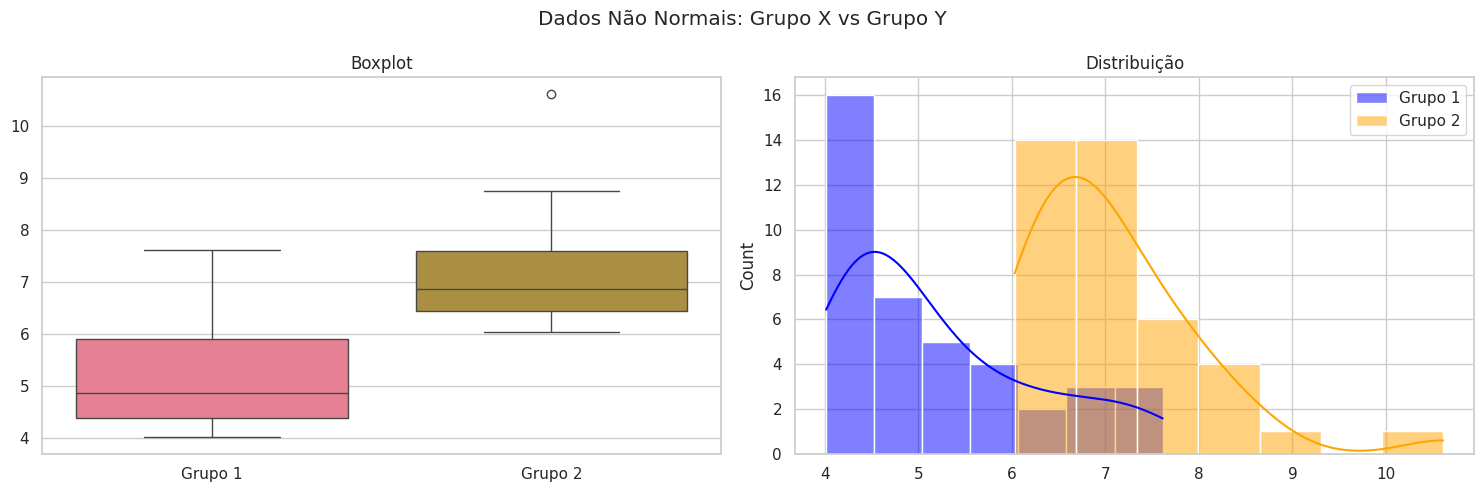

Normalidade Grupo X: ShapiroResult(statistic=np.float64(0.8704476219655382), pvalue=np.float64(0.0002938330606095221))
Normalidade Grupo Y: ShapiroResult(statistic=np.float64(0.8667317893361485), pvalue=np.float64(0.00023547785567402116))

=== Teste Paramétrico (apenas para comparação) ===


,Teste,H0,H1,Média amostra 1,Média amostra 2,Diferença,Estatística t,Graus liberdade,p-valor,Alpha,Homocedasticidade,p-valor Levene,Tamanho efeito (Cohen d),IC 95% diferença
0,Teste t para variâncias iguais,μ₁ = μ₂,μ₁ ≠ μ₂,5.1827,7.0650,-1.8823,-8.5926,78.0000,0.0000,0.0500,True,1.0000,-1.9214,0.0000



=== Teste Não Paramétrico (recomendado) ===


,Teste,H0,H1,Mediana amostra 1,Mediana amostra 2,Estatística U,p-valor,Alpha,Tamanho efeito (r)
0,Mann-Whitney U,Distribuições iguais,Distribuições diferentes,4.8501,6.8538,164.0000,0.0000,0.0500,0.7950


In [ ]:
#Exemplo 3: Amostras independentes (dados não normais)
# Gerar dados não normais
grupoX, grupoY = gerar_dados_medias(mu1=5, mu2=7, nao_normal=True, n=40)

# Visualizar
plotar_comparacao_medias(grupoX, grupoY, "Dados Não Normais: Grupo X vs Grupo Y")

# Verificar normalidade
print("Normalidade Grupo X:", stats.shapiro(grupoX))
print("Normalidade Grupo Y:", stats.shapiro(grupoY))

# Teste paramétrico (apesar dos dados não normais, para comparação)
resultado_t = teste_diferenca_medias_independentes(grupoX, grupoY)
# Teste não paramétrico (apropriado)
resultado_mw = teste_mannwhitneyu(grupoX, grupoY)

# Resultados
print("\n=== Teste Paramétrico (apenas para comparação) ===")
display(pd.DataFrame([resultado_t]))
print("\n=== Teste Não Paramétrico (recomendado) ===")
display(pd.DataFrame([resultado_mw]))

In [ ]:
# Função de Recomendação Automática
def recomendar_teste_medias(amostra1, amostra2, pareado=False, alpha=0.05):
    """
    Recomenda e executa o teste mais apropriado para comparação de médias.
    """
    # Verificar normalidade
    normal1 = stats.shapiro(amostra1).pvalue > alpha
    normal2 = stats.shapiro(amostra2).pvalue > alpha

    if pareado:
        # Dados pareados
        diferencas = np.array(amostra2) - np.array(amostra1)
        normal_diff = stats.shapiro(diferencas).pvalue > alpha

        if normal1 and normal2 and normal_diff:
            print("Recomendação: Teste t pareado (dados normais)")
            return teste_diferenca_medias_pareadas(amostra1, amostra2)
        else:
            print("Recomendação: Teste de Wilcoxon pareado (dados não normais)")
            return teste_wilcoxon_pareado(amostra1, amostra2)
    else:
        # Dados independentes
        if normal1 and normal2:
            # Verificar homogeneidade de variâncias
            levene = stats.levene(amostra1, amostra2)
            if levene.pvalue > alpha:
                print("Recomendação: Teste t para variâncias iguais (dados normais e homocedásticos)")
                return teste_diferenca_medias_independentes(amostra1, amostra2, var_iguais=True)
            else:
                print("Recomendação: Teste t de Welch (dados normais mas heterocedásticos)")
                return teste_diferenca_medias_independentes(amostra1, amostra2, var_iguais=False)
        else:
            print("Recomendação: Teste de Mann-Whitney U (dados não normais)")
            return teste_mannwhitneyu(amostra1, amostra2)

# Exemplo de uso
print("\n=== Exemplo com dados pareados normais ===")
antes, depois = gerar_dados_medias(mu1=80, mu2=85, pareado=True)
resultado = recomendar_teste_medias(antes, depois, pareado=True)
display(pd.DataFrame([resultado]))

print("\n=== Exemplo com dados independentes não normais ===")
grupoX, grupoY = gerar_dados_medias(mu1=5, mu2=8, nao_normal=True)
resultado = recomendar_teste_medias(grupoX, grupoY)
display(pd.DataFrame([resultado]))


=== Exemplo com dados pareados normais ===
Recomendação: Teste t pareado (dados normais)


,Teste,H0,H1,Média antes,Média depois,Média diferenças,Estatística t,Graus liberdade,p-valor,Alpha,Tamanho efeito (Cohen d),IC 95% diferenças
0,Teste t pareado,μ_diferença = 0,μ_diferença ≠ 0,79.9913,84.9274,4.9361,-45.2262,29,0.0000,0.0500,8.2571,"(4.712874447835041, 5.159316486576504)"



=== Exemplo com dados independentes não normais ===
Recomendação: Teste de Mann-Whitney U (dados não normais)


,Teste,H0,H1,Mediana amostra 1,Mediana amostra 2,Estatística U,p-valor,Alpha,Tamanho efeito (r)
0,Mann-Whitney U,Distribuições iguais,Distribuições diferentes,4.7617,7.9256,26.0000,0.0000,0.0500,0.9422
